# Lab 8b: Stochastic Attention Focus in Modern Hopfield Networks

In this lab, we explore how stochastic attention retrieves stored digit patterns from a multi-class modern Hopfield network. We compare stochastic and deterministic retrieval, measure how retrieval accuracy degrades with the inverse temperature $\beta$, and track the step-by-step convergence dynamics of stochastic trajectories starting from corrupted inputs.

> __Learning Objectives__
>
> By the end of this lab, you should be able to:
> * __Compare deterministic and stochastic retrieval at high inverse temperature:__ Retrieve corrupted digit memories using both deterministic and stochastic attention at $\beta = 50$. Observe that stochastic retrieval approximates deterministic retrieval when $\beta$ is large.
> * __Quantify stochastic retrieval accuracy and variance across inverse temperature values:__ Sweep $\beta$ from $50$ to $0.1$, run multiple stochastic retrieval trials per corrupted memory, and compute per-class accuracy with standard deviation. Connect the accuracy degradation to the signal-to-noise transition from L8a.
> * __Analyze mixing time of stochastic trajectories from corrupted inputs:__ Track the maximum attention weight at each step of the Langevin trajectory starting from corrupted memories. Measure how quickly the network locks onto a stored memory at different $\beta$ values.

Let's get started!

___

## Setup, Data, and Prerequisites

We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> __Environment Setup with Include.jl__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Implementations

The notebook uses a local `decode(...)` function to convert flattened state vectors back to image format, and four functions from `src/Compute.jl` that implement the attention update rules:

> * `decode(s; number_of_rows, number_of_cols)`: Converts a flattened state vector $\mathbf{s}$ back to an $n \times n$ image matrix. Reshapes the vector, transposes it to match row-major ordering, and clamps values to $[0,1]$ for grayscale display.
> * `run_deterministic_attention(X, s₀, β, η, T)`: Runs $T$ steps of the deterministic attention update starting from $\mathbf{s}^{0}$ and returns the final state $\mathbf{s}^{T}$.
> * `run_stochastic_attention(X, s₀, β, η, T; seed)`: Runs $T$ steps of the stochastic attention update starting from $\mathbf{s}^{0}$ and returns the final state $\mathbf{s}^{T}$.
> * `run_stochastic_attention_averaged(X, s₀, β, η, T_burn, T_sample; seed)`: Runs `T_burn` burn-in steps (discarded), then runs `T_sample` additional steps and returns the time-averaged attention weight vector $\bar{\mathbf{p}} = \frac{1}{T_{\text{sample}}}\sum_{t} \operatorname{softmax}(\beta\mathbf{X}^{\top}\mathbf{s}^{t})$. Used for stable classification in Task 2.
> * `run_stochastic_attention_trajectory(X, s₀, β, η, T; seed)`: Runs $T$ steps of the stochastic attention update and returns the full $N \times (T+1)$ trajectory matrix, where column $t$ holds the state $\mathbf{s}^{t-1}$.

Let's define the `decode(...)` helper function.

In [2]:
function decode(s::Vector{<:Number}; number_of_rows::Int=28, number_of_cols::Int=28)::Array{Float32,2}
    X = reshape(s, number_of_rows, number_of_cols) |> X -> transpose(X) |> Matrix;
    X̂ = clamp.(Float32.(X), 0.0f0, 1.0f0);
    return X̂
end

decode (generic function with 1 method)

### Constants
Let's set some constants that define the problem size and dataset parameters. The comment next to each constant describes its purpose and values:

In [ ]:
target_digits = [3, 7, 9];                                  # which digit classes to store as memories
K_per_class = 32;                                           # number of images per digit class
number_of_examples = 1000;                                  # how many examples per digit to load from MNIST
number_of_rows = 28;                                        # number of rows in an MNIST image
number_of_cols = 28;                                        # number of cols in an MNIST image
number_of_pixels = number_of_rows * number_of_cols;         # total pixels per image (784)
η = 0.5;                                                    # step size for the attention update
T_steps = 200;                                              # number of update steps per trajectory
θ = 0.90;                                                   # fraction of pixels to corrupt

___

## Background: Stochastic Attention in Modern Hopfield Networks

A modern Hopfield network stores $K$ memory patterns as columns of a matrix $\mathbf{X} \in \mathbb{R}^{N \times K}$. Given a query state $\mathbf{s}$, retrieval works by iterating an update rule that pulls $\mathbf{s}$ toward the stored memory it most resembles. The update rule is controlled by the inverse temperature $\beta > 0$, which sets how sharply attention concentrates on the closest memory.

> __Deterministic attention update:__
>
> At each step $t$, the deterministic update computes softmax attention weights over all $K$ stored memories and moves $\mathbf{s}$ toward their weighted combination:
>
> $$\mathbf{s}^{t+1} = (1 - \eta)\,\mathbf{s}^{t} + \eta\,\mathbf{X}\operatorname{softmax}\!\left(\beta\,\mathbf{X}^{\top}\mathbf{s}^{t}\right)$$
>
> Here $\eta \in (0,1)$ is the step size, and the attention weights $\mathbf{p}^{t} = \operatorname{softmax}(\beta\,\mathbf{X}^{\top}\mathbf{s}^{t}) \in \mathbb{R}^{K}$ concentrate increasingly on the nearest stored memory as $\beta$ increases.

The stochastic version adds a Gaussian noise term at each step, turning the iteration into a discrete Langevin diffusion that explores the energy landscape rather than greedily descending it.

> __Stochastic attention update (Langevin form):__
>
> $$\mathbf{s}^{t+1} = (1 - \eta)\,\mathbf{s}^{t} + \eta\,\mathbf{X}\operatorname{softmax}\!\left(\beta\,\mathbf{X}^{\top}\mathbf{s}^{t}\right) + \sigma\,\boldsymbol{\xi}^{t}$$
>
> where $\boldsymbol{\xi}^{t} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_{N})$ is standard Gaussian noise and $\sigma = \sqrt{2\eta/\beta}$ is the noise amplitude. As $\beta \to \infty$, $\sigma \to 0$ and the stochastic update converges to the deterministic update. As $\beta \to 0$, $\sigma$ grows large and the trajectory becomes noise-dominated.

Retrieved class is determined by summing attention weights over all memories in each class after $T$ steps.

> __Classification by attention weight:__
>
> After $T$ steps, we compute $\mathbf{p}^{T} = \operatorname{softmax}(\beta\,\mathbf{X}^{\top}\mathbf{s}^{T})$ and assign the retrieved state to the class with the highest total weight:
>
> $$\hat{d} = \operatorname*{argmax}_{d \in \mathcal{D}} \sum_{k:\,\text{label}(k) = d} p^{T}_{k}$$
>
> This sums the attention weight across all $K_{\text{per class}}$ stored memories of each digit class $d$ and selects the class with the most total support.

For the full derivation of these update rules, see the [L8a lecture notebook](https://github.com/varnerlab/CHEME-5820-Lectures-Spring-2026).

___

## Task 1: Deterministic vs Stochastic Retrieval (Side-by-Side)
In this task, we corrupt one stored memory from each digit class using random pixel masking and retrieve it using both deterministic and stochastic attention at the same $\beta$. The goal is to see that stochastic retrieval approximates deterministic retrieval when $\beta$ is large.

### Load the MNIST digits dataset
We load the MNIST handwritten digit dataset using `MyMNISTHandwrittenDigitImageDataset(...)`. This returns a dictionary where keys are digit labels (0 to 9) and values are 3D arrays of shape $(28, 28, K)$ holding $K$ grayscale images.

Let's load the dataset and preview a few examples from each target class.

In [23]:
digits_image_dictionary = MyMNISTHandwrittenDigitImageDataset(number_of_examples = number_of_examples);

Let's preview a few examples from each digit class we plan to store:

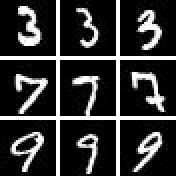

In [24]:
let
    examples = [1, 5, 10];
    all_imgs = [];
    for i in examples
        for d in target_digits
            push!(all_imgs, Gray.(digits_image_dictionary[d][:, :, i]));
        end
    end
    mosaicview(all_imgs..., nrow=length(target_digits), npad=2, fillvalue=Gray(1.0))
end

Each row shows three example images from one digit class (rows: digits 3, 7, 9 from top to bottom). These are raw MNIST grayscale images drawn from the first 1000 examples per class. We will select $K_{\text{per class}} = 32$ images from each class to form the memory matrix.

### Build the multi-class memory matrix
We select $K_{\text{per class}}$ examples from each target digit class, flatten each $28\times 28$ image to a $784$-element vector, center and normalize each vector, and assemble the combined memory matrix.

> __Why center and normalize?__
>
> Centering (subtracting the mean) and normalizing (dividing by the $\ell_{2}$-norm) ensures that all memories contribute equally to the softmax attention weights. Without normalization, images with higher overall brightness would dominate the similarity computation.

We also build a `memory_labels` vector that records which digit class each column belongs to. The code block below builds `X` (normalized, for the update), `X_raw` (unnormalized, for display), and `memory_labels`:

In [25]:
X, X_raw, memory_labels = let

    K_total = K_per_class * length(target_digits);
    X = Array{Float32,2}(undef, number_of_pixels, K_total);
    X_raw = Array{Float32,2}(undef, number_of_pixels, K_total);
    labels = Vector{Int}(undef, K_total);
    ϵ = 1e-12 |> Float32;

    col = 1;
    for d in target_digits
        image_data = digits_image_dictionary[d];
        for k in 1:K_per_class
            s_raw = reshape(transpose(image_data[:, :, k]) |> Matrix, number_of_pixels) |> vec |> x -> convert.(Float32, x);
            X_raw[:, col] = s_raw;

            s_centered = s_raw .- mean(s_raw);
            s_normalized = s_centered ./ (norm(s_centered, 2) + ϵ);
            X[:, col] = s_normalized;

            labels[col] = d;
            col += 1;
        end
    end

    X, X_raw, labels
end;

__Check:__ Let's verify the memory matrix by decoding a few stored memories from each class.

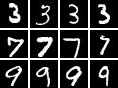

In [26]:
let
    examples_per_class = [1, 2, 3, 4];
    all_imgs = [];
    idxs_by_digit = Dict(d => findall(memory_labels .== d) for d in target_digits);
    for k in examples_per_class
        for d in target_digits
            push!(all_imgs, Gray.(decode(X_raw[:, idxs_by_digit[d][k]])));
        end
    end
    mosaicview(all_imgs..., nrow=length(target_digits), npad=2, fillvalue=Gray(1.0))
end

Each row shows four stored memories decoded from the raw (unnormalized) columns of `X_raw`, with four examples per digit class. The images should be recognizable as their respective digits, confirming that flattening and decoding did not distort the images.

### Corrupt stored memories and retrieve with both methods
We corrupt one stored memory from each class by randomly zeroing out a fraction $\theta$ of its pixels. We then retrieve using both `run_deterministic_attention(...)` and `run_stochastic_attention(...)` at $\beta = 50$.

> __Side-by-side comparison:__
>
> At high $\beta$, the noise amplitude $\sigma = \sqrt{2\eta/\beta}$ in the stochastic update is small. The stochastic trajectory stays close to the deterministic trajectory, so both methods should recover the same digit class with similar attention weight distributions.

Let's corrupt one memory from each digit class and retrieve with both methods.

In [27]:
β_retrieval = 50.0;
T_retrieval = 100;

retrieval_results = let
    n_corrupt = round(Int, θ * number_of_pixels);
    results = [];

    for d in target_digits
        # pick the first memory from this class
        idx = findfirst(memory_labels .== d);

        # randomly select pixels to corrupt (fixed seed per class for reproducibility)
        rng = MersenneTwister(1000 + d);
        mask = shuffle(rng, collect(1:number_of_pixels))[1:n_corrupt];

        # corrupt the normalized version
        ŝ = copy(X[:, idx]);
        ŝ[mask] .= 0.0f0;

        # corrupt the raw version (for display)
        s_raw_corrupt = copy(X_raw[:, idx]);
        s_raw_corrupt[mask] .= 0.0f0;

        # --- Deterministic retrieval ---
        s_det = run_deterministic_attention(X, ŝ, β_retrieval, η, T_retrieval);
        p_det = softmax(β_retrieval .* (transpose(X) * s_det));
        s_det_display = X_raw * p_det;
        cw_det = Dict(c => sum(p_det[memory_labels .== c]) for c in target_digits);

        # --- Stochastic retrieval ---
        s_sto = run_stochastic_attention(X, ŝ, β_retrieval, η, T_retrieval; seed = 2000 + d);
        p_sto = softmax(β_retrieval .* (transpose(X) * s_sto));
        s_sto_display = X_raw * p_sto;
        cw_sto = Dict(c => sum(p_sto[memory_labels .== c]) for c in target_digits);

        push!(results, (
            digit = d, idx = idx,
            raw_original = X_raw[:, idx],
            raw_corrupted = s_raw_corrupt,
            det_recovered = s_det_display,
            sto_recovered = s_sto_display,
            det_predicted = argmax(cw_det),
            sto_predicted = argmax(cw_sto),
            det_weights = cw_det,
            sto_weights = cw_sto
        ));
    end

    results
end;

Let's compare the original, corrupted, deterministic recovery, and stochastic recovery for each digit class. Each row shows one class (original | corrupted | deterministic | stochastic from left to right):

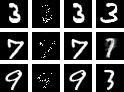

In [28]:
let
    all_imgs = [];
    # outer loop over image types (columns), inner loop over digit classes (rows)
    # ensures column-major mosaicview fill puts each digit class on its own row
    for img_type in [:raw_original, :raw_corrupted, :det_recovered, :sto_recovered]
        for r in retrieval_results
            push!(all_imgs, Gray.(decode(getproperty(r, img_type))));
        end
    end
    mosaicview(all_imgs..., nrow=length(target_digits), npad=4, fillvalue=Gray(1.0))
end

> __What does the recovered image show?__
>
> The recovered image is computed as $\mathbf{X}_{\text{raw}}\,\mathbf{p}$, an attention-weighted mixture of the raw (unnormalized) stored memories. When $\beta$ is large, $\mathbf{p}$ concentrates on a single memory and the display converges to one stored digit. When attention is spread across memories, the display shows a blended average of multiple stored patterns.

At $\beta = 50$, the deterministic and stochastic recovered images should look nearly identical and match the original digit. The corrupted input has 50% of pixels zeroed, yet both retrieval methods recover the correct class. This confirms that high inverse temperature suppresses noise and drives both methods toward the same attractor.

> __Per-class attention weights:__
>
> For each digit class, the table shows the total attention weight assigned to each class by the deterministic and stochastic methods. At high $\beta$, nearly all weight should concentrate on the correct class (a value close to $1.0$), and the two methods should produce similar distributions. If the predicted class matches the digit label, retrieval succeeded.

Let's print the per-class attention weights to compare the two methods numerically:

In [29]:
let
    rows = [];
    for r in retrieval_results
        push!(rows, (
            digit       = r.digit,
            det_pred    = r.det_predicted,
            sto_pred    = r.sto_predicted,
            det_correct = round(r.det_weights[r.digit], digits=4),
            sto_correct = round(r.sto_weights[r.digit], digits=4),
        ));
    end
    DataFrame(rows)
end

Row,digit,det_pred,sto_pred,det_correct,sto_correct
,Int64,Int64,Int64,Float64,Float64
1,3,3,3,1.0,1.0
2,7,7,7,1.0,0.8547
3,9,9,3,1.0,0.0


## Task 2: Stochastic Retrieval Accuracy vs $\beta$
In this task, we measure how stochastic retrieval accuracy changes as $\beta$ decreases. For each $\beta$ value, we corrupt stored memories from each class using random pixel masking and classify using time-averaged attention weights after a burn-in period.

> __Burn-in and time-averaging:__
>
> A single stochastic state $\mathbf{s}^{T}$ is a noisy snapshot that can land in the wrong attractor basin. Instead, we run $T_{\text{burn}}$ steps to let the chain reach stationarity (burn-in, discarded), then average the attention weights over $T_{\text{sample}}$ additional steps: $\bar{\mathbf{p}} = \frac{1}{T_{\text{sample}}}\sum_{t} \operatorname{softmax}(\beta\,\mathbf{X}^{\top}\mathbf{s}^{t})$. This time average reduces variance and gives a stable basis for classification. We run $n_{\text{repeats}}$ independent chains per corrupted input to estimate variance across runs.

Let's define the sweep parameters and run the experiment.

In [30]:
β_values = [500.0, 200.0, 100.0, 50.0, 20.0, 10.0, 5.0, 2.0, 1.0, 0.5, 0.1];  # β sweep from high to low
n_repeats = 2;              # independent stochastic runs per corrupted input
n_trials_per_class = 4;     # stored memories per class to test
T_burn = 2000;              # burn-in steps (discarded before averaging)
T_sample = 500;             # steps to time-average attention weights over

In [31]:
accuracy_table = let

    n_corrupt = round(Int, θ * number_of_pixels);
    results = Vector{NamedTuple{(:β, :digit, :accuracy, :std), Tuple{Float64, Int, Float64, Float64}}}();

    for β in β_values
        for d in target_digits
            idxs = findall(memory_labels .== d);
            repeat_accuracies = Vector{Float64}(undef, n_repeats);

            for rep in 1:n_repeats
                n_correct = 0;
                for trial in 1:n_trials_per_class
                    idx = idxs[trial];

                    # random pixel corruption (fixed mask per trial, same across repeats)
                    rng = MersenneTwister(10000 * trial + d);
                    mask = shuffle(rng, collect(1:number_of_pixels))[1:n_corrupt];
                    ŝ = copy(X[:, idx]);
                    ŝ[mask] .= 0.0f0;

                    # burn-in + time-averaged classification
                    seed = 50000 * rep + 10000 * trial + d;
                    p̄ = run_stochastic_attention_averaged(X, ŝ, β, η, T_burn, T_sample; seed=seed);

                    class_weights = Dict(c => sum(p̄[memory_labels .== c]) for c in target_digits);
                    predicted = argmax(class_weights);

                    if predicted == d
                        n_correct += 1;
                    end
                end
                repeat_accuracies[rep] = n_correct / n_trials_per_class;
            end

            push!(results, (β = β, digit = d,
                accuracy = mean(repeat_accuracies),
                std = std(repeat_accuracies)));
        end
    end

    results
end;

Each row corresponds to one value of $\beta$. The columns `digit_d_acc` and `digit_d_std` report the mean accuracy and standard deviation across $n_{\text{repeats}} = 2$ independent chains for digit class $d$. The `overall_acc` and `overall_std` columns average across all three digit classes. Accuracy near $1.0$ at high $\beta$ and near $0.33$ (random guessing across three classes) at low $\beta$ confirms that burn-in and time-averaging correctly recover the signal-to-noise transition.

Each row corresponds to one value of $\beta$. The columns `digit_d_acc` and `digit_d_std` report the mean accuracy and standard deviation across $n_{\text{repeats}} = 3$ stochastic runs for digit class $d$. The `overall_acc` and `overall_std` columns average across all three digit classes. Accuracy near $1.0$ indicates reliable retrieval; accuracy near $0.33$ indicates random guessing across three classes.

In [32]:
accuracy_df = let
    rows = [];
    for β in β_values
        row = Dict{String, Any}("β" => β);
        for d in target_digits
            r = first(filter(x -> x.β == β && x.digit == d, accuracy_table));
            row["digit_$(d)_acc"] = round(r.accuracy, digits=3);
            row["digit_$(d)_std"] = round(r.std, digits=3);
        end
        overall_acc = mean([r.accuracy for r in accuracy_table if r.β == β]);
        overall_std = mean([r.std for r in accuracy_table if r.β == β]);
        row["overall_acc"] = round(overall_acc, digits=3);
        row["overall_std"] = round(overall_std, digits=3);
        push!(rows, row);
    end
    DataFrame(rows)
end

Row,digit_3_std,digit_9_acc,digit_7_acc,digit_7_std,overall_acc,overall_std,digit_9_std,β,digit_3_acc
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,500.0,1.0
2,0.0,1.0,1.0,0.0,1.0,0.0,0.0,200.0,1.0
3,0.177,0.875,0.5,0.0,0.75,0.118,0.177,100.0,0.875
4,0.0,0.375,0.25,0.0,0.292,0.059,0.177,50.0,0.25
5,0.0,0.125,0.5,0.0,0.375,0.059,0.177,20.0,0.5
6,0.354,0.25,0.375,0.177,0.375,0.295,0.354,10.0,0.5
7,0.354,0.125,0.5,0.354,0.375,0.295,0.177,5.0,0.5
8,0.354,0.125,0.5,0.354,0.375,0.295,0.177,2.0,0.5
9,0.177,0.125,0.5,0.354,0.333,0.236,0.177,1.0,0.375


Let's plot the overall stochastic retrieval accuracy as a function of $\beta$ with error bars showing the standard deviation across repeats:

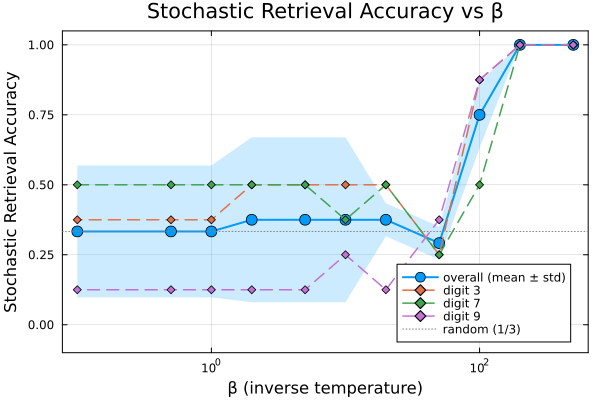

In [33]:
let
    overall_acc = [mean([r.accuracy for r in accuracy_table if r.β == β]) for β in β_values];
    overall_std = [mean([r.std for r in accuracy_table if r.β == β]) for β in β_values];

    p = plot(β_values, overall_acc, ribbon = overall_std,
        xlabel = "β (inverse temperature)", ylabel = "Stochastic Retrieval Accuracy",
        title = "Stochastic Retrieval Accuracy vs β",
        marker = :circle, markersize = 6, linewidth = 2,
        xscale = :log10, legend = :bottomright,
        label = "overall (mean ± std)",
        ylims = (-0.1, 1.05), framestyle = :box, grid = true,
        fillalpha = 0.2);

    # per-class lines
    for d in target_digits
        acc_d = [r.accuracy for r in accuracy_table if r.digit == d];
        std_d = [r.std for r in accuracy_table if r.digit == d];
        plot!(p, β_values, acc_d, marker = :diamond, markersize = 4,
            linewidth = 1.5, linestyle = :dash, label = "digit $(d)");
    end

    # reference line: random guessing = 1/3
    hline!([1.0 / length(target_digits)], linestyle = :dot, color = :gray,
        linewidth = 1, label = "random (1/3)");
    p
end

The plot shows overall retrieval accuracy (solid line with shaded ribbon showing one standard deviation) and per-class accuracy (dashed lines) against $\beta$ on a log scale. Accuracy should be near $1.0$ at high $\beta$ and drop toward the random-guessing baseline ($1/3$, dotted gray line) as $\beta$ decreases. The width of the ribbon reveals the range of $\beta$ where retrieval becomes unreliable across repeated stochastic runs.

### Things to think about
* __Question:__ At which $\beta$ value does stochastic retrieval accuracy start to drop? How does the standard deviation change across the transition?
* __Question:__ Do some digit classes show higher stochastic variance than others? What might cause one class to be more sensitive to noise?
___

## Task 3: Mixing Time from Corrupted Inputs
In this task, we track the stochastic Langevin trajectory step-by-step starting from a corrupted memory and measure how quickly the network locks onto a stored memory at different $\beta$ values.

The mixing time is the first step at which the mean $p_{\max}$ across trajectories exceeds $0.5$. Shorter mixing times indicate faster lock-on to a stored memory. When $\beta$ is too low, $p_{\max}$ never reaches the threshold and the mixing time is reported as "not reached". The `final_pmax` column shows the average attention concentration at step $T = 300$.

> __Maximum attention weight as a convergence metric:__
>
> At each step $t$, we compute the attention weights $\mathbf{p}^{t} = \operatorname{softmax}(\beta\mathbf{X}^{\top}\mathbf{s}^{t})$ and track $p_{\max}^{t} = \max_{k}\,p_{k}^{t}$. When $p_{\max}$ is close to $1$, the network has locked onto a single stored memory. We also track the total attention weight assigned to the correct digit class at each step to see whether the network commits to the right class.

Let's set the parameters and run the trajectories from a corrupted digit-3 memory.

In [34]:
## Task 3: Mixing Time from Corrupted Inputs
In this task, we track the stochastic Langevin trajectory step-by-step starting from a corrupted memory and measure how quickly the network locks onto a stored memory at different $\beta$ values. This is a direct study of the burn-in process: the trajectory shown here is exactly what happens inside the burn-in phase used in Task 2, and the mixing time tells us how many burn-in steps are required before the chain reaches stationarity.

The mixing time is the first step at which the mean $p_{\max}$ across trajectories exceeds $0.5$. Shorter mixing times indicate faster lock-on to a stored memory. When $\beta$ is too low, $p_{\max}$ never reaches the threshold and the mixing time is reported as "not reached". The `final_pmax` column shows the average attention concentration at step $T = 300$.

> __Maximum attention weight as a convergence metric:__
>
> At each step $t$, we compute the attention weights $\mathbf{p}^{t} = \operatorname{softmax}(\beta\mathbf{X}^{\top}\mathbf{s}^{t})$ and track $p_{\max}^{t} = \max_{k}\,p_{k}^{t}$. When $p_{\max}$ is close to $1$, the network has locked onto a single stored memory. We also track the total attention weight assigned to the correct digit class at each step to see whether the network commits to the right class.

Let's set the parameters and run the trajectories from a corrupted digit-3 memory.

UndefVarError: UndefVarError: `In` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [35]:
attention_curves, class_curves = let

    n_corrupt = round(Int, θ * number_of_pixels);
    
    # corrupt the first memory from the source digit class
    idx = findfirst(memory_labels .== source_digit);
    rng_corrupt = MersenneTwister(7777);
    mask = shuffle(rng_corrupt, collect(1:number_of_pixels))[1:n_corrupt];
    ŝ_base = copy(X[:, idx]);
    ŝ_base[mask] .= 0.0f0;

    pmax_curves = Dict{Float64, Vector{Vector{Float64}}}();
    class_weight_curves = Dict{Float64, Vector{Vector{Float64}}}();

    for β in β_mixing
        β_pmax = Vector{Vector{Float64}}();
        β_class = Vector{Vector{Float64}}();

        for run in 1:n_trajectories
            # start from the same corrupted input each time
            s_init = copy(ŝ_base);

            # get full trajectory: N × (T+1) matrix
            traj = run_stochastic_attention_trajectory(X, s_init, β, η, T_mixing; 
                seed = 3000 * run + round(Int, β * 100));

            # compute metrics at each step
            pmax = Vector{Float64}(undef, T_mixing + 1);
            cw = Vector{Float64}(undef, T_mixing + 1);
            for t in 1:(T_mixing + 1)
                s_t = traj[:, t];
                p = softmax(β .* (transpose(X) * s_t));
                pmax[t] = maximum(p);
                cw[t] = sum(p[memory_labels .== source_digit]);
            end
            push!(β_pmax, pmax);
            push!(β_class, cw);
        end
        pmax_curves[β] = β_pmax;
        class_weight_curves[β] = β_class;
    end

    pmax_curves, class_weight_curves
end;

UndefVarError: UndefVarError: `source_digit` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Let's plot the maximum attention weight $p_{\max}$ as a function of step number. Thin lines are individual trajectories, thick lines are means:

In [36]:
let
    steps = 0:T_mixing;
    K_total = K_per_class * length(target_digits);

    p = plot(xlabel = "Step", ylabel = "Max Attention Weight (p_max)",
        title = "Mixing Dynamics from Corrupted Input: p_max vs Step",
        framestyle = :box, grid = true, legend = :right, ylims = (0.0, 1.05));
    
    # reference line: uniform attention = 1/K
    hline!([1.0 / K_total], linestyle = :dot, color = :gray, linewidth = 1, label = "1/K (uniform)");

    colors = [:blue, :green, :orange, :red];
    for (i, β) in enumerate(β_mixing)
        all_curves = attention_curves[β];
        mean_curve = mean(hcat(all_curves...), dims=2) |> vec;

        # plot individual trajectories (thin, transparent)
        for curve in all_curves
            plot!(p, steps, curve, color = colors[i], alpha = 0.2, linewidth = 0.5, label = nothing);
        end

        # plot mean (thick)
        plot!(p, steps, mean_curve, color = colors[i], linewidth = 2.5, label = "β = $(β)");
    end
    p
end

UndefVarError: UndefVarError: `T_mixing` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Each color corresponds to one $\beta$ value. Thin lines are individual Langevin trajectories; thick lines are trajectory means. At high $\beta$, $p_{\max}$ rises from near $1/K$ (uniform attention, gray dotted line) to near $1.0$ within a few steps, indicating rapid lock-on to a single stored memory. At low $\beta$, $p_{\max}$ stays near $1/K$ throughout, meaning the trajectory never concentrates and retrieval fails.

Let's also plot the correct-class attention weight (total weight on digit $3$ memories) at each step:

In [37]:
let
    steps = 0:T_mixing;

    p = plot(xlabel = "Step", ylabel = "Correct-Class Attention Weight",
        title = "Correct-Class (Digit $(source_digit)) Weight vs Step",
        framestyle = :box, grid = true, legend = :right, ylims = (0.0, 1.05));

    # reference line: chance level = K_per_class / K_total
    K_total = K_per_class * length(target_digits);
    hline!([K_per_class / K_total], linestyle = :dot, color = :gray, linewidth = 1, label = "chance (1/3)");

    colors = [:blue, :green, :orange, :red];
    for (i, β) in enumerate(β_mixing)
        all_curves = class_curves[β];
        mean_curve = mean(hcat(all_curves...), dims=2) |> vec;

        # plot individual trajectories (thin, transparent)
        for curve in all_curves
            plot!(p, steps, curve, color = colors[i], alpha = 0.2, linewidth = 0.5, label = nothing);
        end

        # plot mean (thick)
        plot!(p, steps, mean_curve, color = colors[i], linewidth = 2.5, label = "β = $(β)");
    end
    p
end

UndefVarError: UndefVarError: `T_mixing` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

The correct-class weight tracks the total attention falling on all digit-3 memories at each step. At high $\beta$, this rises quickly from the chance level ($1/3$, dotted gray line) to near $1.0$, confirming correct retrieval. At low $\beta$, it stays near chance, indicating the network cannot distinguish the correct class from the stored distractors.

Let's compute the mixing time for each $\beta$ value:

In [38]:
mixing_df = let
    pmax_threshold = 0.5;
    rows = [];

    for β in β_mixing
        all_curves = attention_curves[β];
        mean_curve = mean(hcat(all_curves...), dims=2) |> vec;

        idx = findfirst(mean_curve .>= pmax_threshold);
        mt = idx === nothing ? "not reached" : string(idx - 1);

        push!(rows, Dict(
            "β" => β,
            "mixing_time_steps" => mt,
            "final_pmax" => round(mean_curve[end], digits=4)
        ));
    end
    DataFrame(rows)
end

UndefVarError: UndefVarError: `β_mixing` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Things to think about
* __Question:__ How does the mixing time change as $\beta$ decreases? At which $\beta$ values does the attention never concentrate on a single memory?
* __Question:__ For the low-$\beta$ trajectories, $p_{\max}$ stays near $1/K$. What does this imply about the generated samples compared to the high-$\beta$ samples?
___

## Summary
This lab explored stochastic attention in modern Hopfield networks, comparing it to deterministic retrieval, measuring its accuracy across inverse temperature values, and tracking its convergence dynamics from corrupted inputs.

> __Key Takeaways__
>
> * **Stochastic attention approximates deterministic retrieval at high inverse temperature:** At $\beta = 50$, the noise amplitude in the Langevin update is small enough that stochastic and deterministic retrieval produce similar recovered images and attention weight distributions. The two methods diverge as $\beta$ decreases.
> * **Inverse temperature controls accuracy degradation and stochastic variance:** Stochastic retrieval accuracy is high at large $\beta$ and drops toward random guessing ($1/3$) as $\beta$ decreases. The standard deviation across repeated trials increases at intermediate $\beta$, revealing a transition region where retrieval becomes unreliable.
> * **Mixing time from corrupted inputs predicts retrieval reliability:** High-$\beta$ trajectories lock onto the correct memory within a few steps, while low-$\beta$ trajectories keep attention spread across classes. The step at which the maximum attention weight exceeds $0.5$ provides a quantitative measure of how quickly the network commits to a stored memory.

The stochastic attention framework connects inverse temperature to retrieval performance, variance, and convergence speed in a multi-class setting.
___